 PCA, Factor Analysis,  Clustering, and Classification File (This is the main code file).

### Introduction

I set out to investigate the emotions conveyed by songs and to see if we can classify songs based on the motions they elicit using certain features of the songs. Doing this would give listeners a chance to identify songs based on the emotions they feel at a particular instance, instead of getting song suggestions based on predetermined genres which may not accurately cater to a particular emotion felt at any point in time. 
A second goal for this project was to investigate the moods elicited by the top charting songs (Top 50 songs on spotify). Classifying the moods conveyed by the top charting songs would be important for artist and music enthusiasts in two ways: 

1. We could find out why the songs top the chart by identifying the prevalent moods for any particular time period. This would help us understand the general emotions for any population in the same time period.
2. Artist and music producers would know particular combination of individual music components or features to put together to elicit a particular mood, and be confident to a large extent that they would project that mood in their music, regardless of the genre they have originally been ‘boxed’ into. Armed with this information, creatives can deliberately make chart topping songs by knowing the prevalent emotions within a general population. 

The dataset I am using was created using the Spotify API, Spotipy. Each of these songs were pulled from random playlists to get a variety of different artists, songs, and genres. The features are as follows:

- danceability - how danceable a song is
- energy - how energetic a song is
- key - the key of a song
- loudness - how loud a song is (measured in decibels (dB))
- mode - is the song in a major or minor key?
- speechiness - detects the presence of spoken words on a song
- acousticness - detects the use of acousticness instruments on a song
- instrumentalness - detects the use of vocals on a song
- liveness - how live a song is
- valence - how positive a song is
- tempo
- time_signature

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, VarianceThreshold, SelectFromModel
from sklearn.feature_selection import SelectKBest, mutual_info_regression, mutual_info_classif, chi2
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.preprocessing import KBinsDiscretizer, scale
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV
import warnings
warnings.filterwarnings("ignore")

## Data Preprocessing and Visualization

In [2]:
data=pd.read_csv("spotifytracks_final.csv")
data.head()

,artist,album_name,album_uri,track,trackuri,release_date,id,song_uri,track_href,analysis_url,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Yahir Saldivar,SC-9,spotify:album:74LgaGQ9jTfnBlew28NHj2,SC-9,spotify:track:2y3TKxJAaIauybiS3GKHon,2/1/2024,3FqUPvubYeRCMsdJ02QyZR,spotify:track:3FqUPvubYeRCMsdJ02QyZR,https://api.spotify.com/v1/tracks/3FqUPvubYeRC...,https://api.spotify.com/v1/audio-analysis/3FqU...,...,-5.083,0,0.0282,0.0675,0.000003,0.309,0.884,128.912,152079,3
1,Fuerza Regida,Dolido Pero No Arrepentido,spotify:album:5WPTc1Xa8REVDQ5YazhNgv,TÚ NAME,spotify:track:3FqUPvubYeRCMsdJ02QyZR,2/9/2024,4zfQER4owi8q6NL8Gg63Ya,spotify:track:4zfQER4owi8q6NL8Gg63Ya,https://api.spotify.com/v1/tracks/4zfQER4owi8q...,https://api.spotify.com/v1/audio-analysis/4zfQ...,...,-6.769,0,0.0738,0.2510,0.000074,0.325,0.753,126.000,204816,3
2,Fuerza Regida,Pa las Baby's Y Belikeada,spotify:album:3zu0hJJew2qXZNlselIQk8,CRAZYZ,spotify:track:4zfQER4owi8q6NL8Gg63Ya,10/20/2023,6CvTEtGagmzQvkUzzyKR9k,spotify:track:6CvTEtGagmzQvkUzzyKR9k,https://api.spotify.com/v1/tracks/6CvTEtGagmzQ...,https://api.spotify.com/v1/audio-analysis/6CvT...,...,-5.482,0,0.1100,0.0670,0.004500,0.260,0.635,125.045,143327,4
3,Fuerza Regida,Pa las Baby's Y Belikeada,spotify:album:3zu0hJJew2qXZNlselIQk8,HARLEY QUINN,spotify:track:6CvTEtGagmzQvkUzzyKR9k,10/20/2023,3XfUFGzbr0LmwFVoLXd9cO,spotify:track:3XfUFGzbr0LmwFVoLXd9cO,https://api.spotify.com/v1/tracks/3XfUFGzbr0Lm...,https://api.spotify.com/v1/audio-analysis/3XfU...,...,-5.912,0,0.0828,0.5330,0.000000,0.377,0.560,100.994,163940,1
4,Fuerza Regida,Billete Grande (En Vivo),spotify:album:3qYGLHQB2krhFp27Hm62Ip,Billete Grande (En Vivo),spotify:track:3XfUFGzbr0LmwFVoLXd9cO,8/2/2022,3zFLlF1SvWCt9oZUVPZehW,spotify:track:3zFLlF1SvWCt9oZUVPZehW,https://api.spotify.com/v1/tracks/3zFLlF1SvWCt...,https://api.spotify.com/v1/audio-analysis/3zFL...,...,-5.665,0,0.0373,0.2130,0.000240,0.105,0.881,145.079,129501,3


In [3]:
data.shape

(5300, 23)

This dataset has 5300 rows and 23 columns.

Here I am checking for any missing values and removing those.

In [4]:
insa=data.isna()
print(insa)

      artist  album_name  album_uri  track  trackuri  release_date     id  \
0      False       False      False  False     False         False  False   
1      False       False      False  False     False         False  False   
2      False       False      False  False     False         False  False   
3      False       False      False  False     False         False  False   
4      False       False      False  False     False         False  False   
...      ...         ...        ...    ...       ...           ...    ...   
5295   False       False      False  False     False         False  False   
5296   False       False      False  False     False         False  False   
5297   False       False      False  False     False         False  False   
5298   False       False      False  False     False         False  False   
5299   False       False      False  False     False         False  False   

      song_uri  track_href  analysis_url  ...  loudness   mode  speechiness

In [5]:
data.isnull().sum()

artist              3
album_name          3
album_uri           0
track               3
trackuri            0
release_date        0
id                  0
song_uri            0
track_href          0
analysis_url        0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
dtype: int64

Here we are dropping duplicates.

In [6]:
data.duplicated().value_counts()

False    5096
True      204
Name: count, dtype: int64

In [7]:
data.dropna()

,artist,album_name,album_uri,track,trackuri,release_date,id,song_uri,track_href,analysis_url,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Yahir Saldivar,SC-9,spotify:album:74LgaGQ9jTfnBlew28NHj2,SC-9,spotify:track:2y3TKxJAaIauybiS3GKHon,2/1/2024,3FqUPvubYeRCMsdJ02QyZR,spotify:track:3FqUPvubYeRCMsdJ02QyZR,https://api.spotify.com/v1/tracks/3FqUPvubYeRC...,https://api.spotify.com/v1/audio-analysis/3FqU...,...,-5.083,0,0.0282,0.06750,0.000003,0.3090,0.8840,128.912,152079,3
1,Fuerza Regida,Dolido Pero No Arrepentido,spotify:album:5WPTc1Xa8REVDQ5YazhNgv,TÚ NAME,spotify:track:3FqUPvubYeRCMsdJ02QyZR,2/9/2024,4zfQER4owi8q6NL8Gg63Ya,spotify:track:4zfQER4owi8q6NL8Gg63Ya,https://api.spotify.com/v1/tracks/4zfQER4owi8q...,https://api.spotify.com/v1/audio-analysis/4zfQ...,...,-6.769,0,0.0738,0.25100,0.000074,0.3250,0.7530,126.000,204816,3
2,Fuerza Regida,Pa las Baby's Y Belikeada,spotify:album:3zu0hJJew2qXZNlselIQk8,CRAZYZ,spotify:track:4zfQER4owi8q6NL8Gg63Ya,10/20/2023,6CvTEtGagmzQvkUzzyKR9k,spotify:track:6CvTEtGagmzQvkUzzyKR9k,https://api.spotify.com/v1/tracks/6CvTEtGagmzQ...,https://api.spotify.com/v1/audio-analysis/6CvT...,...,-5.482,0,0.1100,0.06700,0.004500,0.2600,0.6350,125.045,143327,4
3,Fuerza Regida,Pa las Baby's Y Belikeada,spotify:album:3zu0hJJew2qXZNlselIQk8,HARLEY QUINN,spotify:track:6CvTEtGagmzQvkUzzyKR9k,10/20/2023,3XfUFGzbr0LmwFVoLXd9cO,spotify:track:3XfUFGzbr0LmwFVoLXd9cO,https://api.spotify.com/v1/tracks/3XfUFGzbr0Lm...,https://api.spotify.com/v1/audio-analysis/3XfU...,...,-5.912,0,0.0828,0.53300,0.000000,0.3770,0.5600,100.994,163940,1
4,Fuerza Regida,Billete Grande (En Vivo),spotify:album:3qYGLHQB2krhFp27Hm62Ip,Billete Grande (En Vivo),spotify:track:3XfUFGzbr0LmwFVoLXd9cO,8/2/2022,3zFLlF1SvWCt9oZUVPZehW,spotify:track:3zFLlF1SvWCt9oZUVPZehW,https://api.spotify.com/v1/tracks/3zFLlF1SvWCt...,https://api.spotify.com/v1/audio-analysis/3zFL...,...,-5.665,0,0.0373,0.21300,0.000240,0.1050,0.8810,145.079,129501,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5295,NiElsir,Breath Focus,spotify:album:50PlsZ6quB3anjaj5sxPEu,Breath Focus,spotify:track:4ruC7zn3mhvfRFsMCIVG29,11/1/2023,46bnmUJYDniMBcWGoHrvQo,spotify:track:46bnmUJYDniMBcWGoHrvQo,https://api.spotify.com/v1/tracks/46bnmUJYDniM...,https://api.spotify.com/v1/audio-analysis/46bn...,...,-13.870,1,0.0457,0.90100,0.885000,0.0655,0.2090,156.052,134615,4
5296,Yogi Pine,Wooden Castles,spotify:album:0tTBMFO4WGHvTcIxkklCcr,Wooden Castles,spotify:track:46bnmUJYDniMBcWGoHrvQo,4/11/2023,2YvKZgUd5V9Aof04zURv4a,spotify:track:2YvKZgUd5V9Aof04zURv4a,https://api.spotify.com/v1/tracks/2YvKZgUd5V9A...,https://api.spotify.com/v1/audio-analysis/2YvK...,...,-14.052,0,0.0469,0.90000,0.892000,0.1100,0.0527,99.982,202933,3
5297,M I R A G E,Abyss,spotify:album:08lKe9FGRQ6UnAmqOJoCFv,Abyss,spotify:track:2YvKZgUd5V9Aof04zURv4a,2/4/2022,7nwLZlkbmPQzU7q4NlUSKN,spotify:track:7nwLZlkbmPQzU7q4NlUSKN,https://api.spotify.com/v1/tracks/7nwLZlkbmPQz...,https://api.spotify.com/v1/audio-analysis/7nwL...,...,-9.362,1,0.0367,0.02730,0.891000,0.1770,0.1250,90.010,218667,4
5298,wavetearz,cosmic voyage,spotify:album:0zvtmqA8ZoNyf1PdPNQUWX,cosmic voyage,spotify:track:7nwLZlkbmPQzU7q4NlUSKN,4/1/2023,6pykGWJyR0Tp7S0sA47KmH,spotify:track:6pykGWJyR0Tp7S0sA47KmH,https://api.spotify.com/v1/tracks/6pykGWJyR0Tp...,https://api.spotify.com/v1/audio-analysis/6pyk...,...,-7.064,0,0.0400,0.48300,0.908000,0.1060,0.4520,158.046,186646,3


In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.duplicated().value_counts()

False    5096
Name: count, dtype: int64

In [10]:
data = data.drop(columns=['artist','album_name', 'album_uri','track', 'trackuri','release_date','id',
                         'song_uri', 'track_href', 'analysis_url','time_signature', 'duration_ms'])

array([[<Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'key'}>],
       [<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'speechiness'}>],
       [<Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>],
       [<Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>, <Axes: >]], dtype=object)

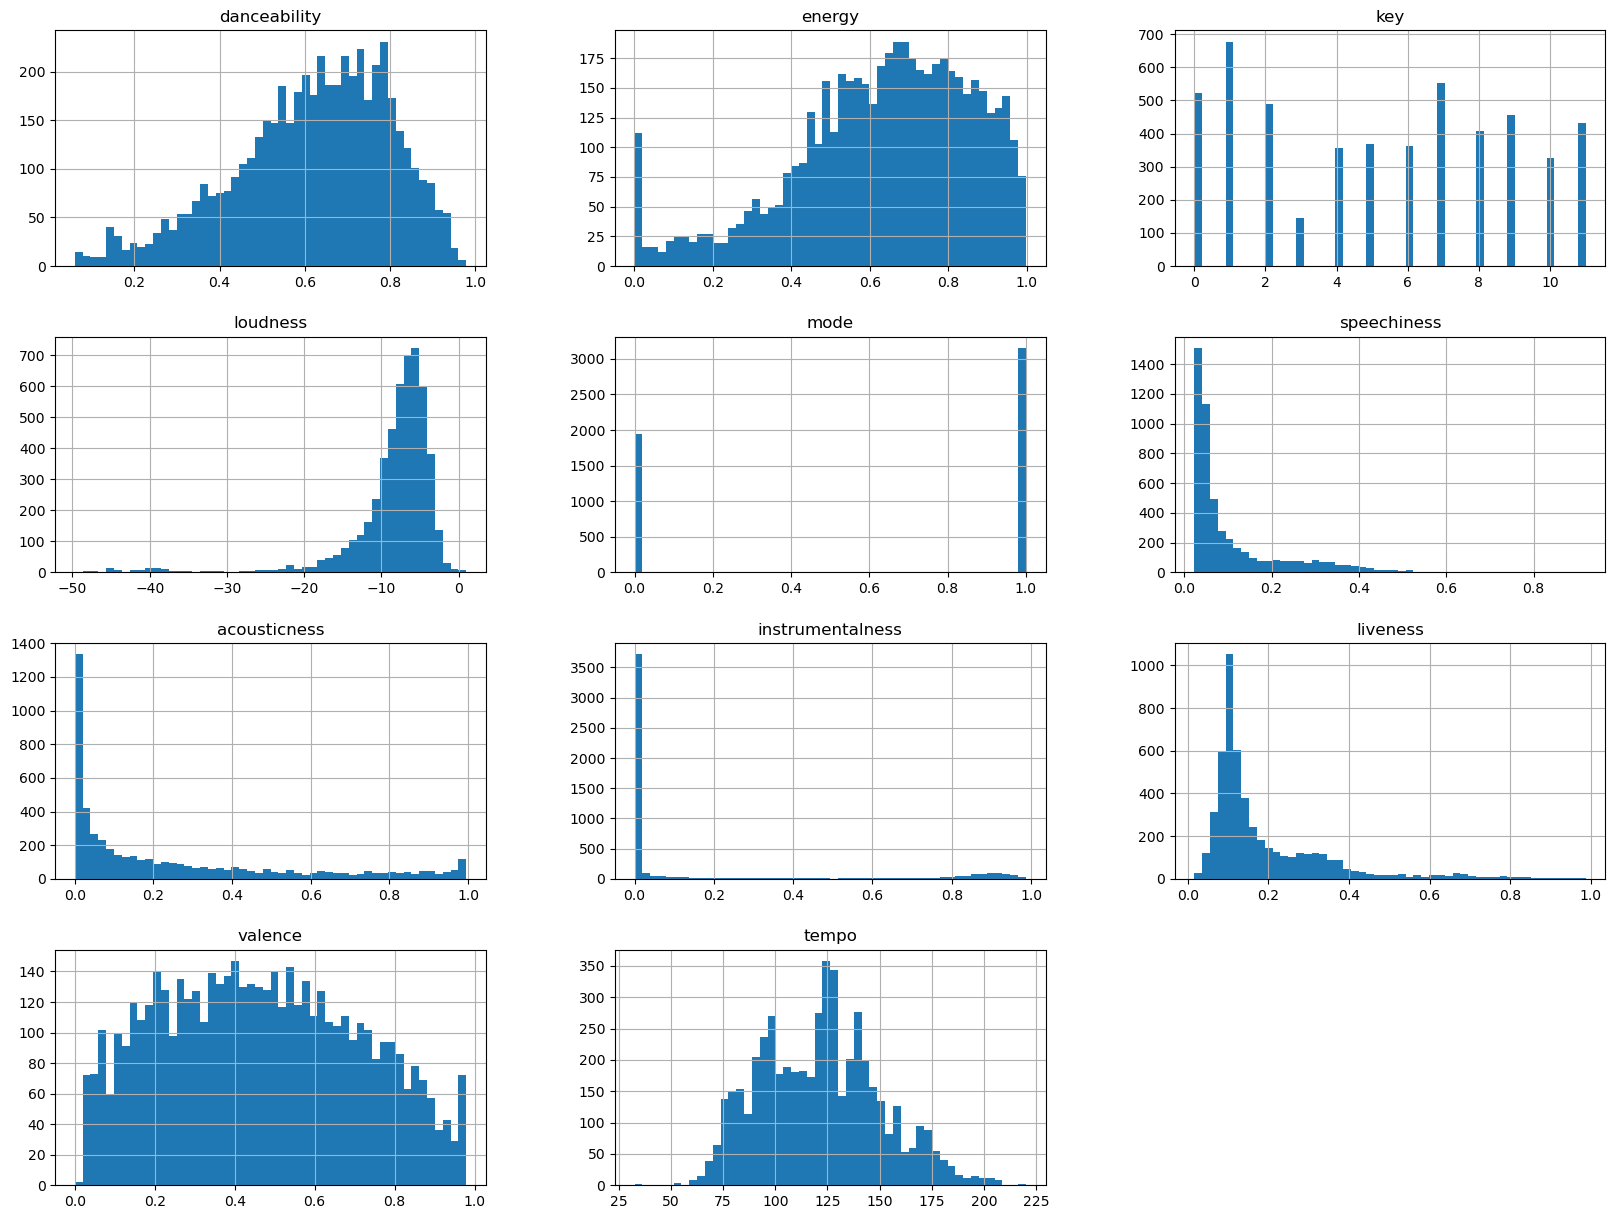

In [11]:
data.hist(bins=50,figsize=(20,15))

These are the statistical distributions of each of the numerical variables. We can see that most of these columns have a normal distribution (with left and right skews) with the exception of the mode and key since they have a fixed number of values. 

Here I normalize the loudness, tempo, and key variables since the values do not go from 0 to 1.

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
loudness_d = data['loudness'].values.reshape(-1, 1)
tempo_d = data['tempo'].values.reshape(-1, 1)

data['loudness']= scaler.fit_transform(loudness_d)
data['tempo']= scaler.fit_transform(tempo_d)

In [13]:
key_d = data['key'].values.reshape(-1, 1)
data['key']= scaler.fit_transform(key_d)

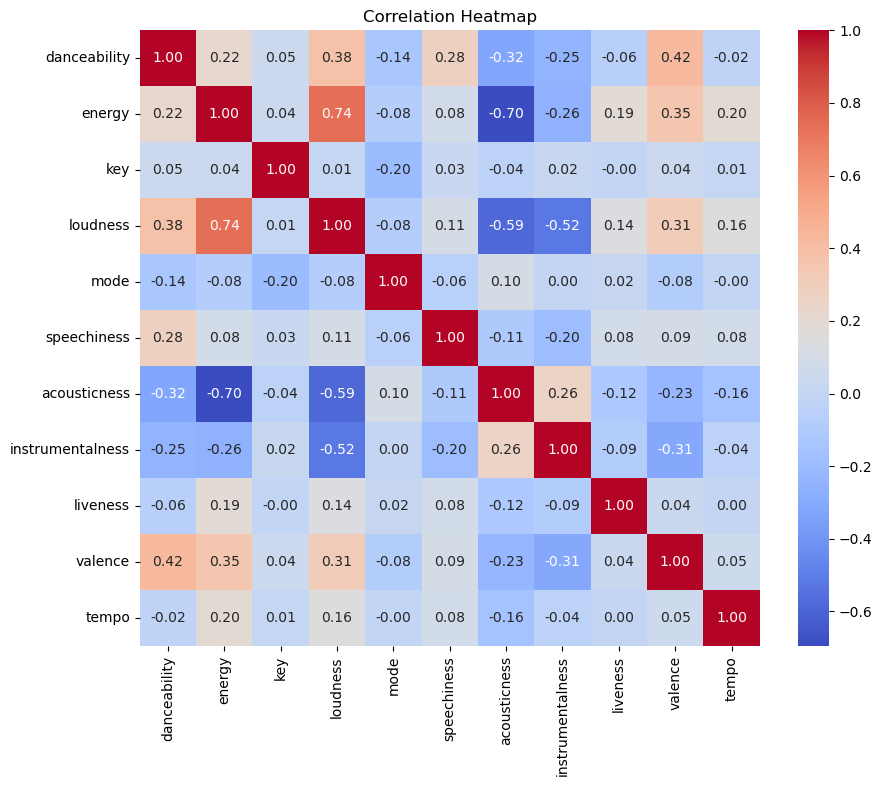

In [14]:
# Calculate the correlation matrix
correlation_matrix1 = data.corr()
correlation_matrix1

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

This is the correlation matrix of all of the numerical variables. We can see that the highest correlations are with loudness and energy (strongly positive), acousticness and loudness (moderately negative), acousticness and energy (strongly negative), and instrumentalness and loudness (moderately negative).

## PCA and FA

Now, we will perform PCA  and FA on the dataset.

In [15]:
from factor_analyzer import FactorAnalyzer

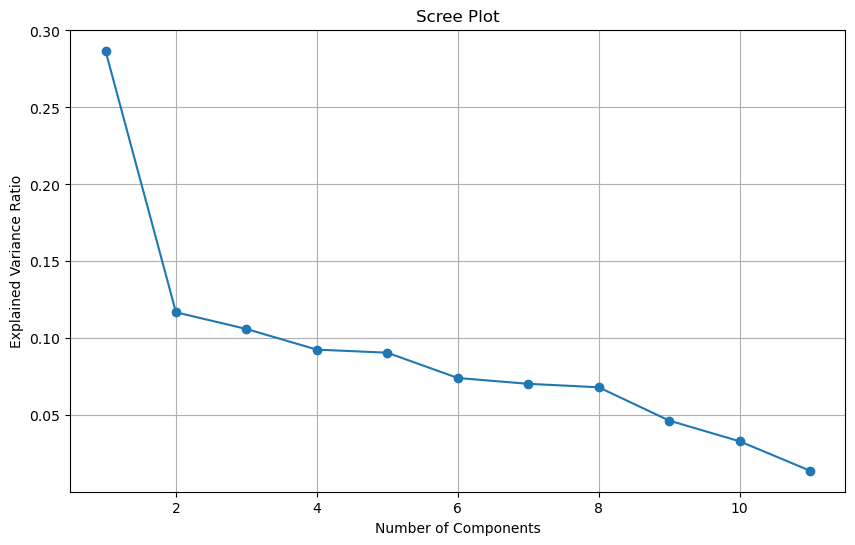

In [16]:
Xpc = data

# Standardize the numerical features to have mean=0 and variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xpc)

# Create a PCA object
pca = PCA()

# Fit PCA to the standardized data
pca.fit(X_scaled)

# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

Based on this scree plot above, I decided that 4 components would be the best option. Two may not cover enough or explain enough variance in the data. so next best real elbow may be 4. 

In [17]:
# Perform PCA with components =4
pca = PCA(n_components=4) 
#psa_r=pca.fit(X_scaled)
scores1=pca.fit_transform(X_scaled)
pca_summary = pd.DataFrame({
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Explained Variance Ratio': pca.explained_variance_ratio_.cumsum()
})
print(pca_summary)


   Explained Variance Ratio  Cumulative Explained Variance Ratio
0                  0.286812                             0.286812
1                  0.116934                             0.403745
2                  0.106097                             0.509843
3                  0.092682                             0.602525


In [18]:
#At least 60% is explained (transformed by the PCA)

In [19]:
# factor Analysis with components=6
fa = FactorAnalyzer(n_factors=4, rotation='varimax')
fa.fit(X_scaled)

# Getting factor loadings
loadings = pd.DataFrame(fa.loadings_, columns=[f'Factor {i+1}' for i in range(4)], index=data.columns)
print(loadings)

                  Factor 1  Factor 2  Factor 3  Factor 4
danceability      0.017525  1.002722  0.037605 -0.074077
energy            0.970805  0.211953 -0.002938 -0.063717
key               0.010823  0.023853  0.014049 -0.312828
loudness          0.686806  0.363454 -0.279703 -0.026447
mode             -0.023619 -0.093212  0.006830  0.631992
speechiness       0.028697  0.251935 -0.117624 -0.048552
acousticness     -0.652082 -0.296439  0.047153  0.081863
instrumentalness -0.208359 -0.291187  0.932649 -0.054643
liveness          0.194939 -0.044135 -0.074680  0.020521
valence           0.225859  0.398113 -0.141358 -0.062343
tempo             0.213597 -0.002785 -0.003427 -0.007320


In [20]:
sorted_loadings = loadings['Factor 1'].sort_values(ascending=False)
print(sorted_loadings)

energy              0.970805
loudness            0.686806
valence             0.225859
tempo               0.213597
liveness            0.194939
speechiness         0.028697
danceability        0.017525
key                 0.010823
mode               -0.023619
instrumentalness   -0.208359
acousticness       -0.652082
Name: Factor 1, dtype: float64


Factor 1: loud highly energetic and somewhat positive

In [21]:
sorted_loadings2 = loadings['Factor 2'].sort_values(ascending=False)
print(sorted_loadings2)

danceability        1.002722
valence             0.398113
loudness            0.363454
speechiness         0.251935
energy              0.211953
key                 0.023853
tempo              -0.002785
liveness           -0.044135
mode               -0.093212
instrumentalness   -0.291187
acousticness       -0.296439
Name: Factor 2, dtype: float64


Factor 2: Motivational-Happy-Danceable 

In [22]:
sorted_loadings3 = loadings['Factor 3'].sort_values(ascending=False)
print(sorted_loadings3)

instrumentalness    0.932649
acousticness        0.047153
danceability        0.037605
key                 0.014049
mode                0.006830
energy             -0.002938
tempo              -0.003427
liveness           -0.074680
speechiness        -0.117624
valence            -0.141358
loudness           -0.279703
Name: Factor 3, dtype: float64


Factor 3: sad- instrumental 

In [23]:
sorted_loadings4 = loadings['Factor 4'].sort_values(ascending=False)
print(sorted_loadings4)

mode                0.631992
acousticness        0.081863
liveness            0.020521
tempo              -0.007320
loudness           -0.026447
speechiness        -0.048552
instrumentalness   -0.054643
valence            -0.062343
energy             -0.063717
danceability       -0.074077
key                -0.312828
Name: Factor 4, dtype: float64


Factor 4: sound on a major key

Looking at each of these loadings, we can find a few things studying the positive and negative values on these loadings. For the first factor(Factor 1), the energy and loudness values are positively high with low but positive valence and tempo values. I therefore derived that the songs in this group/ Factor are LOUD AND HIGHLY ENERGETIC but somewhat positive.  For the second factor (Factor 2),  the highest positive values on the loading is for danceability, with somewhat posite loudness, and valence, and spechiness values. This shows that the songs here are DANCEABLE and POSITIVE/ MORIVATIONAL songs. The third factor(fACTOR 3)- has a high positive values for Instrumentalmenss and low positive values for Acousticness and danceability with low negative vaues of energy, valence, loudness and tempo, indicating these could be INSTRUMENTAL SAD SONGS. For the last factor(factor 4), Mode has quite a high positive value indicating ( played in a major key) with low acoustics and liveness positive value.This may indicate LIVE PERFORMANCE IN A MAJOR KEY OR JUST HAPPY NOISE. I will take this loadings into consideration when we go through the clustering step. I  will attempt to derive moods from the different clusters,comparing with the derived moods from our factor loadings. This is to double-check the clustering results with the derived moods from the loadings and vice versa.

## Clustering

Here I am reloading the original dataset to see what kinds of results we get from clustering and also see if they are similar to the PCA/ FA loadings.

In [24]:
data1=pd.read_csv("spotifytracks_final.csv")
data1.head()

,artist,album_name,album_uri,track,trackuri,release_date,id,song_uri,track_href,analysis_url,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Yahir Saldivar,SC-9,spotify:album:74LgaGQ9jTfnBlew28NHj2,SC-9,spotify:track:2y3TKxJAaIauybiS3GKHon,2/1/2024,3FqUPvubYeRCMsdJ02QyZR,spotify:track:3FqUPvubYeRCMsdJ02QyZR,https://api.spotify.com/v1/tracks/3FqUPvubYeRC...,https://api.spotify.com/v1/audio-analysis/3FqU...,...,-5.083,0,0.0282,0.0675,0.000003,0.309,0.884,128.912,152079,3
1,Fuerza Regida,Dolido Pero No Arrepentido,spotify:album:5WPTc1Xa8REVDQ5YazhNgv,TÚ NAME,spotify:track:3FqUPvubYeRCMsdJ02QyZR,2/9/2024,4zfQER4owi8q6NL8Gg63Ya,spotify:track:4zfQER4owi8q6NL8Gg63Ya,https://api.spotify.com/v1/tracks/4zfQER4owi8q...,https://api.spotify.com/v1/audio-analysis/4zfQ...,...,-6.769,0,0.0738,0.2510,0.000074,0.325,0.753,126.000,204816,3
2,Fuerza Regida,Pa las Baby's Y Belikeada,spotify:album:3zu0hJJew2qXZNlselIQk8,CRAZYZ,spotify:track:4zfQER4owi8q6NL8Gg63Ya,10/20/2023,6CvTEtGagmzQvkUzzyKR9k,spotify:track:6CvTEtGagmzQvkUzzyKR9k,https://api.spotify.com/v1/tracks/6CvTEtGagmzQ...,https://api.spotify.com/v1/audio-analysis/6CvT...,...,-5.482,0,0.1100,0.0670,0.004500,0.260,0.635,125.045,143327,4
3,Fuerza Regida,Pa las Baby's Y Belikeada,spotify:album:3zu0hJJew2qXZNlselIQk8,HARLEY QUINN,spotify:track:6CvTEtGagmzQvkUzzyKR9k,10/20/2023,3XfUFGzbr0LmwFVoLXd9cO,spotify:track:3XfUFGzbr0LmwFVoLXd9cO,https://api.spotify.com/v1/tracks/3XfUFGzbr0Lm...,https://api.spotify.com/v1/audio-analysis/3XfU...,...,-5.912,0,0.0828,0.5330,0.000000,0.377,0.560,100.994,163940,1
4,Fuerza Regida,Billete Grande (En Vivo),spotify:album:3qYGLHQB2krhFp27Hm62Ip,Billete Grande (En Vivo),spotify:track:3XfUFGzbr0LmwFVoLXd9cO,8/2/2022,3zFLlF1SvWCt9oZUVPZehW,spotify:track:3zFLlF1SvWCt9oZUVPZehW,https://api.spotify.com/v1/tracks/3zFLlF1SvWCt...,https://api.spotify.com/v1/audio-analysis/3zFL...,...,-5.665,0,0.0373,0.2130,0.000240,0.105,0.881,145.079,129501,3


Dropping the key and mode variables this time, because these make the resulting clusters look abnormal. Therefore, I thought it was best to remove these completely. See bar plots for mode and key in earlier sections for reference.

In [25]:
data1 = data1.drop(['album_uri', 'trackuri','release_date', 'id', 'song_uri', 'track_href', 'analysis_url',
                  'duration_ms', 'key', 'mode'], axis = 1)
data1.head()

,artist,album_name,track,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,Yahir Saldivar,SC-9,SC-9,0.760,0.747,-5.083,0.0282,0.0675,0.000003,0.309,0.884,128.912,3
1,Fuerza Regida,Dolido Pero No Arrepentido,TÚ NAME,0.809,0.849,-6.769,0.0738,0.2510,0.000074,0.325,0.753,126.000,3
2,Fuerza Regida,Pa las Baby's Y Belikeada,CRAZYZ,0.793,0.761,-5.482,0.1100,0.0670,0.004500,0.260,0.635,125.045,4
3,Fuerza Regida,Pa las Baby's Y Belikeada,HARLEY QUINN,0.751,0.601,-5.912,0.0828,0.5330,0.000000,0.377,0.560,100.994,1
4,Fuerza Regida,Billete Grande (En Vivo),Billete Grande (En Vivo),0.773,0.836,-5.665,0.0373,0.2130,0.000240,0.105,0.881,145.079,3


I am normalizing the same variables from the previous PCA analysis.

In [26]:
from sklearn import preprocessing

loudness = data1[['loudness']].values.reshape(-1, 1)
min_max_scaler = preprocessing.MinMaxScaler()
loudness_scaled = min_max_scaler.fit_transform(loudness)
data1['loudness'] = pd.DataFrame(loudness_scaled)

tempo = data1[['tempo']].values.reshape(-1,1)
min_max_scaler = preprocessing.MinMaxScaler()
tempo_scaled = min_max_scaler.fit_transform(tempo)
data1['tempo'] = pd.DataFrame(tempo_scaled)

In [27]:
data1.head()

,artist,album_name,track,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,Yahir Saldivar,SC-9,SC-9,0.760,0.747,0.880545,0.0282,0.0675,0.000003,0.309,0.884,0.513794,3
1,Fuerza Regida,Dolido Pero No Arrepentido,TÚ NAME,0.809,0.849,0.847273,0.0738,0.2510,0.000074,0.325,0.753,0.498279,3
2,Fuerza Regida,Pa las Baby's Y Belikeada,CRAZYZ,0.793,0.761,0.872671,0.1100,0.0670,0.004500,0.260,0.635,0.493191,4
3,Fuerza Regida,Pa las Baby's Y Belikeada,HARLEY QUINN,0.751,0.601,0.864185,0.0828,0.5330,0.000000,0.377,0.560,0.365050,1
4,Fuerza Regida,Billete Grande (En Vivo),Billete Grande (En Vivo),0.773,0.836,0.869060,0.0373,0.2130,0.000240,0.105,0.881,0.599930,3


I am also dropping the time_signature and instrumentalness variables because time_signature only has 4 distinct values, and there are a lot of values that are towards zero for instrumentalness.

In [28]:
data1 = data1.drop(['time_signature', 'instrumentalness'], axis = 1)
data1

,artist,album_name,track,danceability,energy,loudness,speechiness,acousticness,liveness,valence,tempo
0,Yahir Saldivar,SC-9,SC-9,0.760,0.747,0.880545,0.0282,0.06750,0.3090,0.8840,0.513794
1,Fuerza Regida,Dolido Pero No Arrepentido,TÚ NAME,0.809,0.849,0.847273,0.0738,0.25100,0.3250,0.7530,0.498279
2,Fuerza Regida,Pa las Baby's Y Belikeada,CRAZYZ,0.793,0.761,0.872671,0.1100,0.06700,0.2600,0.6350,0.493191
3,Fuerza Regida,Pa las Baby's Y Belikeada,HARLEY QUINN,0.751,0.601,0.864185,0.0828,0.53300,0.3770,0.5600,0.365050
4,Fuerza Regida,Billete Grande (En Vivo),Billete Grande (En Vivo),0.773,0.836,0.869060,0.0373,0.21300,0.1050,0.8810,0.599930
...,...,...,...,...,...,...,...,...,...,...,...
5295,NiElsir,Breath Focus,Breath Focus,0.598,0.383,0.707136,0.0457,0.90100,0.0655,0.2090,0.658392
5296,Yogi Pine,Wooden Castles,Wooden Castles,0.725,0.451,0.703544,0.0469,0.90000,0.1100,0.0527,0.359658
5297,M I R A G E,Abyss,Abyss,0.636,0.710,0.796100,0.0367,0.02730,0.1770,0.1250,0.306529
5298,wavetearz,cosmic voyage,cosmic voyage,0.714,0.745,0.841451,0.0400,0.48300,0.1060,0.4520,0.669016


let's remove the non-numerical variables to make the dataset ready for clustering.

In [29]:
# remove song names, artist and id before clustering
data_features = data1.copy()
data_features = data_features.drop(['artist','album_name', 'track'],axis=1)

Now, I am performing KMeans clustering with a range of values to see which value gives us the best k.

In [30]:
from sklearn.cluster import KMeans

Sum_of_squared_distances = []
# trying with the k-values 1 to 14
K = range(1,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(data_features)
    Sum_of_squared_distances.append(km.inertia_)

In [31]:
from sklearn.metrics import silhouette_score
# getting the silhouette score for each k-value
for n_clusters in range(2,15):
    clusterer = KMeans (n_clusters=n_clusters)
    preds = clusterer.fit_predict(data_features)
    centers = clusterer.cluster_centers_
    
    # outputting the results
    score = silhouette_score (data_features, preds, metric='euclidean')
    print ("For n_clusters = {}, silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, silhouette score is 0.3760164873700026)
For n_clusters = 3, silhouette score is 0.22103183292786396)
For n_clusters = 4, silhouette score is 0.20882627909436344)
For n_clusters = 5, silhouette score is 0.18685166298641834)
For n_clusters = 6, silhouette score is 0.19220501331025375)
For n_clusters = 7, silhouette score is 0.19042248957015206)
For n_clusters = 8, silhouette score is 0.17421450427325721)
For n_clusters = 9, silhouette score is 0.1704158410578501)
For n_clusters = 10, silhouette score is 0.1602400589117039)
For n_clusters = 11, silhouette score is 0.16356364703244022)
For n_clusters = 12, silhouette score is 0.15915343430072657)
For n_clusters = 13, silhouette score is 0.16073744164339285)
For n_clusters = 14, silhouette score is 0.1608365887576911)


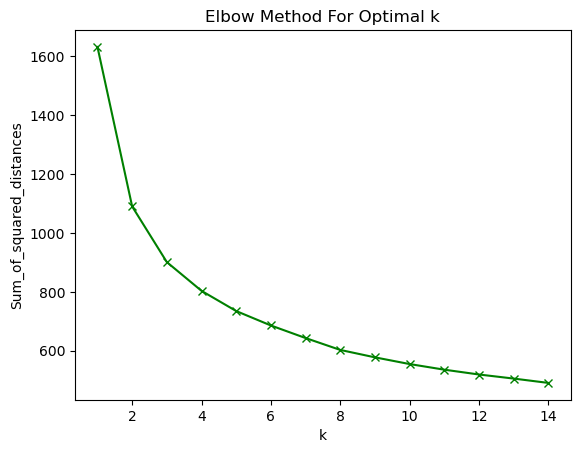

In [32]:
plt.plot(K, Sum_of_squared_distances, 'gx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

Based on the scree plot above, I decided that 4 clusters would be the optimal choice.

In [33]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(data_features)

KMeans(n_clusters=4)

Below, I am predicting the k-means results onto our dataset.

In [34]:
y_kmeans = kmeans.predict(data_features)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_features)

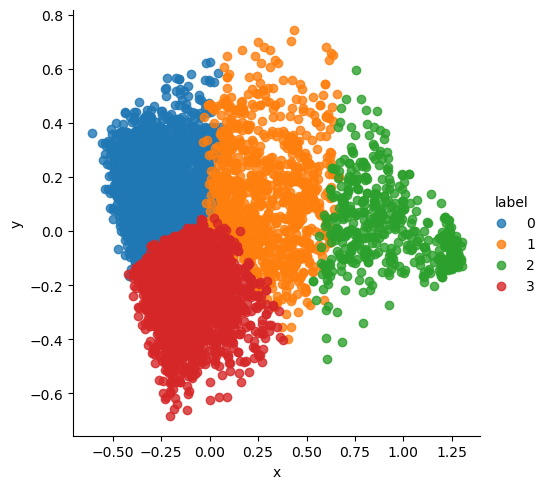

In [35]:
pc = pd.DataFrame(principal_components)
pc['label'] = y_kmeans
pc.columns = ['x', 'y','label']

#plot data with seaborn
cluster = sns.lmplot(data=pc, x='x', y='y', hue='label', 
                   fit_reg=False, legend=True, legend_out=True)

Above is a plot of the four clusters on the first two principal components. As you can see, there is separation between each of the clusters with the minimal overlap. I think the clustering results are reasonable.

In [36]:
# Dump components relations with features:
print (pd.DataFrame(pca.components_,columns=data_features.columns,index = ['PC-1','PC-2']))

      danceability    energy  loudness  speechiness  acousticness  liveness  \
PC-1     -0.241874 -0.510158 -0.235388    -0.058479       0.70092 -0.061818   
PC-2      0.371585 -0.169071 -0.029060     0.075258       0.38771 -0.093108   

       valence     tempo  
PC-1 -0.348847 -0.074856  
PC-2  0.811963 -0.092517  


In [37]:
data1['label'] = y_kmeans

# shuffle dataset
data1 = data1.sample(frac=1)
data1['label'].value_counts()

label
0    1979
3    1889
1     955
2     477
Name: count, dtype: int64

Here, I have added the cluster labels back into the dataset, and these are the counts of each cluster. There is a bit of class imbalance so I will investigate that during the classification step.

## Choosing the Moods

The values below for each cluster are the mean values for each Spotify features. I am comparing these values with the loadings from the PCA/ FA analysis and choosing the moods based on validation/agreement between the clustering labels and the Factor Loadings criteria.

In [38]:
data_features[data1['label']==0].mean().sort_values(ascending = False)

loudness        0.849067
danceability    0.726591
energy          0.723668
valence         0.703149
tempo           0.465498
liveness        0.190195
speechiness     0.139343
acousticness    0.108968
dtype: float64

In this first cluster, loudness, danceability, energy and valence have the highest values. Tempo is quite moderate. These values seem to correlate with Factor  2 in the PCA analysis. Therefore, this is our **Danceable, Happy and Energetic/Positive-Motivational** mood songs.

In [39]:
data_features[data1['label']==1].mean().sort_values(ascending = False)

loudness        0.802703
danceability    0.624438
acousticness    0.556533
energy          0.508605
tempo           0.467007
valence         0.448410
liveness        0.164519
speechiness     0.110749
dtype: float64

In this second cluster, loudness and danceability have pretty high values, while acousticness and energy tempo and valence have moderate values. Some of the values correlate to Factor #1 from the Factor analysis. Since the values for this dataset were quite similar to the first cluster, I determined that this mood is our **Loud-Danceable/Sing-Along/Danceable** mood. 

In [40]:
data[data1['label']==2].mean().sort_values(ascending = False)

acousticness        0.885625
mode                0.762527
loudness            0.546915
instrumentalness    0.543521
key                 0.441672
tempo               0.392165
danceability        0.349898
valence             0.188131
energy              0.163010
liveness            0.150806
speechiness         0.046236
dtype: float64

In this cluster, acousticness has the highest value out of all the other values, with mode having a high value and loudness being moderate, with lower priority to key and , tempo, danceability and low energy. This most resembles our factor 3 loadings from the FA with instrumentation given priority and acousticness, with low (negative) energy, low valence and low loudness. This highly resembles a Calm and Chill mood song. I therefore determine that this mood is **Calm/Chill** from comparing the cluster mean values and the Factor 3 loadings as they agree.

In [42]:
data[data1['label']==3].mean().sort_values(ascending = False)

loudness            0.845451
energy              0.709589
mode                0.624190
danceability        0.582363
tempo               0.501366
key                 0.471922
valence             0.299876
liveness            0.209047
instrumentalness    0.162003
speechiness         0.107997
acousticness        0.076272
dtype: float64

For the last cluster, loudness, energy, and mode have high values, with moderate values for dancebility, tempo and key and low valence. This suggests songs with loud sounds and energy given low priority to the music, instrumentation, key or valence. This resembles loud hard rock songs or just loud sounds. This cluster seems to somewhat resemble Factor #4 of the PCA/ FA analysis in the sense that the mode (major key) is given priority in that factor indicative if a lively sound, with live acousticness. Therefore, this is our **loud energetic but mainly noise** mood cluster. 

In [43]:
data[data1['label'] == 0].head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.760,0.747,0.000000,0.880545,0,0.0282,0.0675,0.000003,0.309,0.884,0.513794
1,0.809,0.849,0.363636,0.847273,0,0.0738,0.2510,0.000074,0.325,0.753,0.498279
2,0.793,0.761,0.454545,0.872671,0,0.1100,0.0670,0.004500,0.260,0.635,0.493191
4,0.773,0.836,0.636364,0.869060,0,0.0373,0.2130,0.000240,0.105,0.881,0.599930
5,0.725,0.801,0.363636,0.851713,1,0.0372,0.0333,0.000006,0.156,0.642,0.547093


In [44]:
data[data1['label'] == 1].head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
3,0.751,0.601,0.454545,0.864185,0,0.0828,0.533,0.000000,0.3770,0.560,0.365050
7,0.717,0.704,0.090909,0.881394,1,0.0695,0.570,0.000001,0.0956,0.717,0.530230
8,0.832,0.621,0.000000,0.805810,1,0.0608,0.691,0.000162,0.1830,0.967,0.519617
11,0.776,0.701,0.818182,0.877783,1,0.0254,0.513,0.000000,0.0902,0.603,0.423859
12,0.819,0.480,0.454545,0.843385,1,0.0489,0.685,0.000002,0.1160,0.759,0.434558


In [45]:
data[data1['label'] == 2].head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
80,0.544,0.4150,0.363636,0.751697,1,0.0343,0.842,0.858000,0.0915,0.0662,0.679619
83,0.388,0.2910,0.272727,0.725253,1,0.0421,0.774,0.000019,0.0874,0.5100,0.274205
84,0.410,0.1740,0.272727,0.755782,1,0.0328,0.767,0.001970,0.1140,0.0694,0.387949
86,0.371,0.2680,0.090909,0.773524,1,0.0281,0.748,0.051700,0.1040,0.1650,0.373697
104,0.563,0.0481,0.545455,0.378355,1,0.0364,0.936,0.828000,0.1090,0.4750,0.459695


In [46]:
data[data1['label'] == 3].head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
29,0.699,0.541,0.000000,0.883308,1,0.0826,0.0628,0.000000,0.0916,0.365,0.351203
35,0.576,0.715,0.090909,0.867284,0,0.0354,0.3350,0.000003,0.0772,0.497,0.892233
37,0.944,0.607,0.090909,0.894084,1,0.1600,0.2830,0.000003,0.0773,0.184,0.466647
42,0.881,0.551,0.181818,0.854357,1,0.1230,0.0205,0.160000,0.1900,0.196,0.466051
43,0.554,0.763,0.000000,0.860159,0,0.0711,0.1570,0.000000,0.0968,0.224,0.705768


Note that data_feautures and data were used interchangebly to map feautures to the cluster labels. This was not a mistake. 
Data is the original dataframe variable of the dataset. Data_features is the dataset with instrumentalness and other categorical features removed and used for the cluster analysis. Both were used to understand the clusters in comparison with the FA analysis loadings where certain features were important to further understand the correaltion between the loadings and clusters in contex.

## Classification

Now that I have all of our moods, now we can actually do the classification step. I am adding the cluster labels to the dataset and this now acts as our target variable. We then create training and test sets and do a 70/30 split. I also decided to have a validation set as well, which is 50% of the test set.

In [47]:
y_train = data1['label']
training = data1.drop(['label', 'artist', 'album_name', 'track'], axis = 1)

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(training, y_train, test_size=0.30, random_state=33)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.50, random_state=33)

Since there are 4 possible values for the target variable, this becomes a multilabel classification problem. Therefore, we have chosen a few classifiers that are able to perform multilabel classification.

## KNN

The first model I have chosen is KNN. Here, I will train the model without any hyperparameters and see what our results are.

In [49]:
from sklearn import neighbors
from sklearn.neighbors import KNeighborsClassifier

In [50]:
knnclf = neighbors.KNeighborsClassifier()
knnclf = knnclf.fit(X_train, y_train)

In [51]:
pred = knnclf.predict(X_train)
metrics.accuracy_score(y_true = y_train, y_pred = pred)

0.9636118598382749

In [52]:
pred_val = knnclf.predict(X_val)
metrics.accuracy_score(y_true = y_val, y_pred = pred_val)

0.9383647798742139

In [53]:
pd.DataFrame(metrics.confusion_matrix(y_val, pred_val))

,0,1,2,3
0,276,1,0,13
1,9,127,2,4
2,0,2,64,0
3,12,6,0,279


In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       290
           1       0.93      0.89      0.91       142
           2       0.97      0.97      0.97        66
           3       0.94      0.94      0.94       297

    accuracy                           0.94       795
   macro avg       0.94      0.94      0.94       795
weighted avg       0.94      0.94      0.94       795



So far, the results for KNN are very good. The overall accuracy is about 94%, and all of the precision, recall, and F1-scores for each of the values are above 90%. 

Even though the results are very good for this model, I will perform hyperparameter tuning using grid search and 5-fold cross validation to see if there are any changes with the model.

In [55]:
param = {'n_neighbors': np.arange(2, 30, 1), 'weights': ['uniform', 'distance']}

gs = GridSearchCV(estimator = KNeighborsClassifier() , param_grid = param, scoring = 'f1', cv = 5)

In [56]:
gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]),
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [57]:
gs.best_params_

{'n_neighbors': 2, 'weights': 'uniform'}

The results from grid search is that 2 is the best k-value and 'uniform' should be used for the weights. We will also use Euclidean distance for the final model as well.

In [58]:
knnclf = neighbors.KNeighborsClassifier(2, weights='uniform', metric = 'euclidean')
knnclf = knnclf.fit(X_train, y_train)

In [59]:
pred = knnclf.predict(X_train)
metrics.accuracy_score(y_true = y_train, y_pred = pred)

0.9638814016172507

In [60]:
pred_val = knnclf.predict(X_val)
metrics.accuracy_score(y_true = y_val, y_pred = pred_val)

0.9106918238993711

In [61]:
pd.DataFrame(metrics.confusion_matrix(y_val, pred_val))

,0,1,2,3
0,277,3,0,10
1,13,124,1,4
2,0,5,61,0
3,28,7,0,262


In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       290
           1       0.89      0.87      0.88       142
           2       0.98      0.92      0.95        66
           3       0.95      0.88      0.91       297

    accuracy                           0.91       795
   macro avg       0.92      0.91      0.92       795
weighted avg       0.91      0.91      0.91       795



Even after hyperparameter tuning, the results for this model are very reasonable. The overall accuracy is about 91%, and each of the precision, recall, and F1-scores are all above 90%. Therefore, I will consider using this model on the final test set.

## Random Forest

The next model we are trying out is a Random Forest model. We are following the exact same process from KNN: training a default model, performing hyperparameter tuning, and then training the model one more time with the hyperparameters chosen.

In [63]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

In [64]:
clf = clf.fit(X_train, y_train)

In [65]:
pred = clf.predict(X_train)
metrics.accuracy_score(y_true = y_train, y_pred = pred)

1.0

In [66]:
pred_val = clf.predict(X_val)
metrics.accuracy_score(y_true = y_val, y_pred = pred_val)

0.9559748427672956

In [67]:
pd.DataFrame(metrics.confusion_matrix(y_val, pred_val))

,0,1,2,3
0,283,0,0,7
1,5,129,3,5
2,0,3,63,0
3,4,8,0,285


In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       290
           1       0.92      0.91      0.91       142
           2       0.95      0.95      0.95        66
           3       0.96      0.96      0.96       297

    accuracy                           0.96       795
   macro avg       0.95      0.95      0.95       795
weighted avg       0.96      0.96      0.96       795



The accuracy is very high at 96%. Each of the precision, recall, and F1-scores are all above 95%. Now, we are performing hyperparameter tuning.

In [69]:
param = {'min_samples_split': [5, 10, 15, 20, 30, 40, 50], 'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]}

gs = GridSearchCV(estimator = RandomForestClassifier() , param_grid = param, scoring = 'f1', cv = 5)

In [70]:
gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [5, 10, 15, 20, 30, 40, 50],
                         'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             scoring='f1')

In [71]:
gs.best_params_

{'max_depth': 1, 'min_samples_split': 5, 'n_estimators': 10}

Now, I am trying the random forest model with a max_depth of 1, min_samples_split of 5, and n_estimators of 10. We are also adding in the value "balanced" for the class_weight parameter to help a bit with the class imbalance.

In [72]:
best_clf = RandomForestClassifier(class_weight = 'balanced', max_depth = 1, min_samples_split = 5, n_estimators = 10)

In [73]:
best_clf = best_clf.fit(X_train, y_train)

In [74]:
pred = best_clf.predict(X_train)
metrics.accuracy_score(y_true = y_train, y_pred = pred)

0.8388140161725067

In [75]:
pred_val = best_clf.predict(X_val)
metrics.accuracy_score(y_true = y_val, y_pred = pred_val)

0.8352201257861636

In [76]:
pd.DataFrame(metrics.confusion_matrix(y_val, pred_val))

,0,1,2,3
0,270,0,3,17
1,39,68,22,13
2,0,6,60,0
3,17,9,5,266


In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88       290
           1       0.82      0.48      0.60       142
           2       0.67      0.91      0.77        66
           3       0.90      0.90      0.90       297

    accuracy                           0.84       795
   macro avg       0.80      0.80      0.79       795
weighted avg       0.84      0.84      0.83       795



The overall accuracy for the random forest model is about 84%. The recall for the second cluster is about 48% and the precision for the third cluster is 67%. Therefore, this may not be the best classifier to use for the final step as the KNN performs better still.

## Decision Trees

Next, I am trying decision trees and following the exact same process.

In [78]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier() 

In [79]:
clf = clf.fit(X_train, y_train)

In [80]:
pred = clf.predict(X_train)
metrics.accuracy_score(y_true = y_train, y_pred = pred)

1.0

In [81]:
pred_val = clf.predict(X_val)
metrics.accuracy_score(y_true = y_val, y_pred = pred_val)

0.9358490566037736

In [82]:
pd.DataFrame(metrics.confusion_matrix(y_val, pred_val))

,0,1,2,3
0,275,4,0,11
1,6,126,6,4
2,0,6,60,0
3,4,9,1,283


In [83]:
print(metrics.classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       290
           1       0.87      0.89      0.88       142
           2       0.90      0.91      0.90        66
           3       0.95      0.95      0.95       297

    accuracy                           0.94       795
   macro avg       0.92      0.92      0.92       795
weighted avg       0.94      0.94      0.94       795



The avg values for the decision tree default model are all above 89%. We will see what happens after hyperparameter tuning.

In [84]:
from sklearn.model_selection import GridSearchCV
param = {'min_samples_split': [5, 10, 15, 20, 30, 40, 50], 'max_depth': [2, 3, 4, None]}

gs = GridSearchCV(estimator = DecisionTreeClassifier(), param_grid = param, scoring = 'f1', cv = 5)

In [85]:
gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 3, 4, None],
                         'min_samples_split': [5, 10, 15, 20, 30, 40, 50]},
             scoring='f1')

In [86]:
gs.best_params_

{'max_depth': 2, 'min_samples_split': 5}

After grid search, the model came back with a max_depth of 2, and min_samples_split of 5. We are also adding in the value "balanced" for the class_weight like we did in the random forest model.

In [87]:
best_clf = DecisionTreeClassifier(class_weight = 'balanced', max_depth = 2, min_samples_split = 5)

In [88]:
best_clf = best_clf.fit(X_train, y_train)

In [89]:
pred = best_clf.predict(X_train)
metrics.accuracy_score(y_true = y_train, y_pred = pred)

0.8727762803234501

In [90]:
pred_val = best_clf.predict(X_val)
metrics.accuracy_score(y_true = y_val, y_pred = pred_val)

0.8654088050314466

In [91]:
pd.DataFrame(metrics.confusion_matrix(y_val, pred_val))

,0,1,2,3
0,258,19,0,13
1,4,107,19,12
2,0,9,57,0
3,22,9,0,266


In [92]:
print(metrics.classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       290
           1       0.74      0.75      0.75       142
           2       0.75      0.86      0.80        66
           3       0.91      0.90      0.90       297

    accuracy                           0.87       795
   macro avg       0.83      0.85      0.84       795
weighted avg       0.87      0.87      0.87       795



The results for the decision tree model are a bit better than the random forest model, however not as good as the KNN Model. However, the overall accuracy is about 87%, and most of the precision, recall, and F1-scores are around 70-90%.

## SVM

The next model I am going to try is the SVM classifier model with the rbf kernel.

In [93]:
estimator = SVC(kernel ='rbf')
estimator.fit(X_train, y_train)

SVC()

In [94]:
pred = estimator.predict(X_train)
metrics.accuracy_score(y_true = y_train, y_pred = pred)

0.9884097035040431

In [95]:
pred_val = estimator.predict(X_val)
metrics.accuracy_score(y_true = y_val, y_pred = pred_val)

0.9823899371069182

In [96]:
print(metrics.classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       290
           1       0.97      0.99      0.98       142
           2       0.98      0.98      0.98        66
           3       0.98      0.99      0.98       297

    accuracy                           0.98       795
   macro avg       0.98      0.98      0.98       795
weighted avg       0.98      0.98      0.98       795



The results for this default model are quite good, as some of the scores are very close to 99%. This is suspicious, because there might be overfitting happening. Next I will do hyperparameter tuning.

In [97]:
param = {'C': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10], 'gamma': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10 ,100, 1000]}

gs = GridSearchCV(estimator = SVC(kernel ='rbf'), param_grid = param, scoring = 'f1', cv = 5)

In [98]:
gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10],
                         'gamma': [1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100,
                                   1000]},
             scoring='f1')

In [99]:
gs.best_params_

{'C': 1e-05, 'gamma': 1e-05}

For both the C and gamma values, the value 1e-05 was chosen.

In [100]:
best_clf = SVC(kernel ='rbf', C = 1e-05, gamma = 1e-05)
best_clf.fit(X_train, y_train)

SVC(C=1e-05, gamma=1e-05)

In [101]:
pred = best_clf.predict(X_train)
metrics.accuracy_score(y_true = y_train, y_pred = pred)

0.37142857142857144

In [102]:
pred_val = best_clf.predict(X_val)
metrics.accuracy_score(y_true = y_val, y_pred = pred_val)

0.36477987421383645

In [103]:
pd.DataFrame(metrics.confusion_matrix(y_val, pred_val))

,0,1,2,3
0,290,0,0,0
1,142,0,0,0
2,66,0,0,0
3,297,0,0,0


In [104]:
print(metrics.classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.36      1.00      0.53       290
           1       0.00      0.00      0.00       142
           2       0.00      0.00      0.00        66
           3       0.00      0.00      0.00       297

    accuracy                           0.36       795
   macro avg       0.09      0.25      0.13       795
weighted avg       0.13      0.36      0.19       795



Here, there are only predictions for one of the possible values. Therefore, SVM is definitely not the model to use here.

## AdaBoost

Lastly, i am going to try the AdaBoost model.

In [105]:
from sklearn.ensemble import AdaBoostClassifier
clf = AdaBoostClassifier() 

In [106]:
clf = clf.fit(X_train, y_train)

In [107]:
pred = clf.predict(X_train)
metrics.accuracy_score(y_true = y_train, y_pred = pred)

0.8690026954177897

In [108]:
pred_val = clf.predict(X_val)
metrics.accuracy_score(y_true = y_val, y_pred = pred_val)

0.869182389937107

In [109]:
pd.DataFrame(metrics.confusion_matrix(y_val, pred_val))

,0,1,2,3
0,234,8,0,48
1,2,124,10,6
2,0,11,55,0
3,3,15,1,278


In [110]:
print(metrics.classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.98      0.81      0.88       290
           1       0.78      0.87      0.83       142
           2       0.83      0.83      0.83        66
           3       0.84      0.94      0.88       297

    accuracy                           0.87       795
   macro avg       0.86      0.86      0.86       795
weighted avg       0.88      0.87      0.87       795



So far, the performance metrics look reasonable. The overall accuracy is about 87% and the other metrics are in the 78-88% range. Let us see what hyperparameter tuning does.

In [111]:
param = {'learning_rate': [0.0001, 0.0005, 0.001, 0.005, 0.1, 0.5, 1, 2],
        'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]}

gs = GridSearchCV(estimator = AdaBoostClassifier(), param_grid = param, scoring = 'f1', cv = 5)

In [112]:
gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(),
             param_grid={'learning_rate': [0.0001, 0.0005, 0.001, 0.005, 0.1,
                                           0.5, 1, 2],
                         'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             scoring='f1')

In [113]:
gs.best_params_

{'learning_rate': 0.0001, 'n_estimators': 10}

A learning rate of 0.0001 and n_estimators of 10 was chosen as the optimal parameters.

In [114]:
best_clf = AdaBoostClassifier(learning_rate = 0.0001, n_estimators = 10)

In [115]:
best_clf = best_clf.fit(X_train, y_train)

In [116]:
pred = best_clf.predict(X_train)
metrics.accuracy_score(y_true = y_train, y_pred = pred)

0.6816711590296496

In [117]:
pred_val = best_clf.predict(X_val)
metrics.accuracy_score(y_true = y_val, y_pred = pred_val)

0.6968553459119496

In [118]:
pd.DataFrame(metrics.confusion_matrix(y_val, pred_val))

,0,1,2,3
0,277,0,0,13
1,48,0,0,94
2,2,0,0,64
3,20,0,0,277


In [119]:
print(metrics.classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.80      0.96      0.87       290
           1       0.00      0.00      0.00       142
           2       0.00      0.00      0.00        66
           3       0.62      0.93      0.74       297

    accuracy                           0.70       795
   macro avg       0.35      0.47      0.40       795
weighted avg       0.52      0.70      0.60       795



Here, there are only results for 2 of the song groups. Therefore, AdaBoost is also not the best model to use.

Now that we tried all of our models, we have decided to use our KNN model to predict the top 50 songs of 2023 From the Spotify Top 50 Songs Chart. KNN has the best performance metrice considering accuracy, Precision and Recall.

## Final Results: Applying our Best Model to the Top 50 Songs

The following dataset is the top 50 songs of 2023 from Spotify as mentioned previously.

In [120]:
new_data=pd.read_csv("df_2023c.csv")
new_data.head()

,artist_name,track_name,danceability,valence,energy,loudness,acousticness,instrumentalness,liveness,speechiness,key,tempo,mode,duration_ms,time_signature
0,Miley Cyrus,Flowers,0.706,0.632,0.691,-4.775,0.0584,0.000070,0.0232,0.0633,0,118.048,1,200600,4
1,SZA,Kill Bill,0.644,0.418,0.735,-5.747,0.0521,0.144000,0.1610,0.0391,8,88.980,1,153947,4
2,Harry Styles,As It Was,0.520,0.662,0.731,-5.338,0.3420,0.001010,0.3110,0.0557,6,173.930,0,167303,4
3,Jung Kook,Seven (feat. Latto) (Explicit Ver.),0.790,0.872,0.831,-4.185,0.3120,0.000000,0.0797,0.0440,11,124.987,1,183551,4
4,Eslabon Armado,Ella Baila Sola,0.668,0.834,0.758,-5.176,0.4830,0.000019,0.0837,0.0332,5,147.989,0,165671,3


I am normalizing the loudness and tempo variables just like the training set. We will filter out the variables we will use in the next step to leaving the key and mode in will not impact our final results.

In [121]:
loudness = new_data[['loudness']].values.reshape(-1,1)
min_max_scaler = preprocessing.MinMaxScaler()
loudness_scaled = min_max_scaler.fit_transform(loudness)
new_data['loudness'] = pd.DataFrame(loudness_scaled)

tempo = new_data[['tempo']].values.reshape(-1,1)
min_max_scaler = preprocessing.MinMaxScaler()
tempo_scaled = min_max_scaler.fit_transform(tempo)
new_data['tempo'] = pd.DataFrame(tempo_scaled)

In [122]:
new_data

,artist_name,track_name,danceability,valence,energy,loudness,acousticness,instrumentalness,liveness,speechiness,key,tempo,mode,duration_ms,time_signature
0,Miley Cyrus,Flowers,0.706,0.632,0.691,0.748174,0.05840,0.000070,0.0232,0.0633,0,0.373118,1,200600,4
1,SZA,Kill Bill,0.644,0.418,0.735,0.623606,0.05210,0.144000,0.1610,0.0391,8,0.160518,1,153947,4
2,Harry Styles,As It Was,0.520,0.662,0.731,0.676022,0.34200,0.001010,0.3110,0.0557,6,0.781834,0,167303,4
3,Jung Kook,Seven (feat. Latto) (Explicit Ver.),0.790,0.872,0.831,0.823786,0.31200,0.000000,0.0797,0.0440,11,0.423870,1,183551,4
4,Eslabon Armado,Ella Baila Sola,0.668,0.834,0.758,0.696783,0.48300,0.000019,0.0837,0.0332,5,0.592104,0,165671,3
5,Taylor Swift,Cruel Summer,0.552,0.564,0.702,0.628733,0.11700,0.000021,0.1050,0.1570,9,0.753046,1,178427,4
6,Metro Boomin,Creepin' (with The Weeknd & 21 Savage),0.715,0.172,0.620,0.590542,0.41700,0.000000,0.0822,0.0484,1,0.226124,0,221520,4
7,Rema,Calm Down (with Selena Gomez),0.799,0.811,0.802,0.694220,0.42900,0.001280,0.1710,0.0371,11,0.292373,1,239318,4
8,Bizarrap,"Shakira: Bzrp Music Sessions, Vol. 53",0.778,0.498,0.632,0.642445,0.27400,0.000000,0.0915,0.0493,2,0.402784,0,218289,4
9,Taylor Swift,Anti-Hero,0.637,0.533,0.643,0.518006,0.13000,0.000002,0.1420,0.0519,4,0.219234,1,200690,4


Here, I am making a new test set with only the features and we will predict based off of these values.

In [134]:
#new_data_test = new_data.filter(['danceability','energy','loudness','acousticness', 'instrumentalnes','liveness', 'valence','tempo', 'speechiness', 'liveness'])
new_data_test = new_data.filter(['danceability','energy','loudness','speechiness','acousticness','liveness','valence','tempo'])

I am now using the optimal KNN model on the final dataset.

In [135]:
bestclass = neighbors.KNeighborsClassifier(2, weights='uniform', metric = 'euclidean')
bestclass.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=2)

In [136]:
new_data_knnpreds = bestclass.predict(new_data_test)

In [137]:
new_data['label'] = new_data_knnpreds

In [138]:
new_data.head()

,artist_name,track_name,danceability,valence,energy,loudness,acousticness,instrumentalness,liveness,speechiness,key,tempo,mode,duration_ms,time_signature,label
0,Miley Cyrus,Flowers,0.706,0.632,0.691,0.748174,0.0584,0.000070,0.0232,0.0633,0,0.373118,1,200600,4,0
1,SZA,Kill Bill,0.644,0.418,0.735,0.623606,0.0521,0.144000,0.1610,0.0391,8,0.160518,1,153947,4,3
2,Harry Styles,As It Was,0.520,0.662,0.731,0.676022,0.3420,0.001010,0.3110,0.0557,6,0.781834,0,167303,4,0
3,Jung Kook,Seven (feat. Latto) (Explicit Ver.),0.790,0.872,0.831,0.823786,0.3120,0.000000,0.0797,0.0440,11,0.423870,1,183551,4,0
4,Eslabon Armado,Ella Baila Sola,0.668,0.834,0.758,0.696783,0.4830,0.000019,0.0837,0.0332,5,0.592104,0,165671,3,0


In [139]:
new_data['label'].value_counts()

label
0    26
3    14
1    10
Name: count, dtype: int64

To make this easier to read, we will map the actual mood names to each of the clusters.

In [140]:
new_data['label'] = new_data['label'].map({0: 'Danceable,Energetic,Happy/Motivational', 1: 'Loud/Sing-Along/Danceable', 2: 'Calm/Chill', 3: 'Loud/Energertic/noisy'})

In [141]:
new_data['label'].value_counts()

label
Danceable,Energetic,Happy/Motivational    26
Loud/Energertic/noisy                     14
Loud/Sing-Along/Danceable                 10
Name: count, dtype: int64

Therefore, according to the KNN classifier, I was able to predict 26 songs from the Danceable,Energetic,Happy/Motivational cluster. This made up most of the songs from the top 50 chart. 14 from the Loud/Energertic/noisy cluster, and only 10 from the Loud/Sing-along and Danceable mood cluster. There were no songs predicted from the calm/chill mood cluster.

## Conclusion

To conclude, we found that Danceable high energy Happy/Motivationalsongs topped the chart in 2023. Most of the songs seemed to be motivational with upbeat daceable happy tunes. 28% of the songs in the chart were loud, energetic but mostly noise little lyric depth. this were sound heavy, according to the model. There were no chill/calm songs on the chart.  I think that the KNN model used to predict these songs had good predictions for the most part. I would be curious to see how it does with more data or another set of songs from a different year. This can be the foundation for a recommender system to output songs based on the mood a user inputs. 

## Thank you!